In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [32]:
df = pd.read_csv("ab_test_data.csv")

df.head()

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0


In [33]:
print("Розмір датасету:", df.shape)

print(df.dtypes)

Розмір датасету: (19998, 4)
user_id       object
timestamp     object
test_group    object
conversion     int64
dtype: object


In [60]:
# Перетворимо пропуски

print(df.isna().sum())

user_id       0
timestamp     0
test_group    0
conversion    0
date          0
dtype: int64


In [61]:
# Перетворимо дублікати

duplicates = df['user_id'].duplicated().sum()

print(f'Duplicated users: {duplicates}')

Duplicated users: 0


In [62]:
# Перевіримо кількість учасників, які попали в кожну групу

print(df['test_group'].value_counts())

test_group
a    10013
b     9985
Name: count, dtype: int64


In [58]:
# Перевіримо конверсії

print(df['conversion'].value_counts())

conversion
0    18498
1     1500
Name: count, dtype: int64


In [34]:
# Перетворимо timestamp в формат дати та часу

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.dtypes)

user_id               object
timestamp     datetime64[ns]
test_group            object
conversion             int64
dtype: object


In [36]:
# Агрегація по групам: кількість користувачів, конверсії, CR

summary = df.groupby("test_group").agg(
    users=("user_id", "nunique"),
    conversions=("conversion", "sum"),
    conversion_rate=("conversion", "mean")
).reset_index()

summary["conversion_rate_percent"] = summary["conversion_rate"] * 100

summary

,test_group,users,conversions,conversion_rate,conversion_rate_percent
0,a,10013,611,0.061021,6.102067
1,b,9985,889,0.089034,8.903355


In [37]:
# Дати та тривалість тесту

start_date = df["timestamp"].min()
end_date = df["timestamp"].max()

duration_days = (end_date.normalize() - start_date.normalize()).days + 1

print("Дата початку тесту:", start_date)
print("Дата закінчення тесту:", end_date)
print("Тривалість тесту в днях:", duration_days)

Дата початку тесту: 2023-07-03 01:42:34.033708
Дата закінчення тесту: 2023-07-25 01:41:19.152664
Тривалість тесту в днях: 23


In [38]:
# Підготовка даних для z-test

conversions = summary["conversions"].values
users = summary["users"].values

print("Конверсії:", conversions)
print("Користувачі:", users)

Конверсії: [611 889]
Користувачі: [10013  9985]


In [92]:
# 8. Z-test для двох пропорцій

z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=users,
    alternative="two-sided"
)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

Z-statistic: -7.519675939906207
p-value: 5.491217728445103e-14


In [40]:
# Довірчі інтервали 95% для конверсій

ci_low, ci_high = proportion_confint(
    count=conversions,
    nobs=users,
    alpha=0.05,
    method="normal"
)

summary["ci_low"] = ci_low
summary["ci_high"] = ci_high

summary["ci_low_percent"] = summary["ci_low"] * 100
summary["ci_high_percent"] = summary["ci_high"] * 100

summary

,test_group,users,conversions,conversion_rate,conversion_rate_percent,ci_low,ci_high,ci_low_percent,ci_high_percent
0,a,10013,611,0.061021,6.102067,0.056332,0.065709,5.633219,6.570916
1,b,9985,889,0.089034,8.903355,0.083448,0.094620,8.344754,9.461957


In [41]:
# Розрахунок uplift

cr_a = summary.loc[summary["test_group"] == "a", "conversion_rate"].iloc[0]
cr_b = summary.loc[summary["test_group"] == "b", "conversion_rate"].iloc[0]

absolute_uplift = cr_b - cr_a
relative_uplift = absolute_uplift / cr_a

print("Абсолютний uplift:", absolute_uplift)
print("Абсолютний uplift в п.п.:", absolute_uplift * 100)
print("Відносний uplift:", relative_uplift)
print("Відносний uplift %:", relative_uplift * 100)

Абсолютний uplift: 0.028012877200550658
Абсолютний uplift в п.п.: 2.8012877200550657
Відносний uplift: 0.4590719139265364
Відносний uplift %: 45.90719139265364


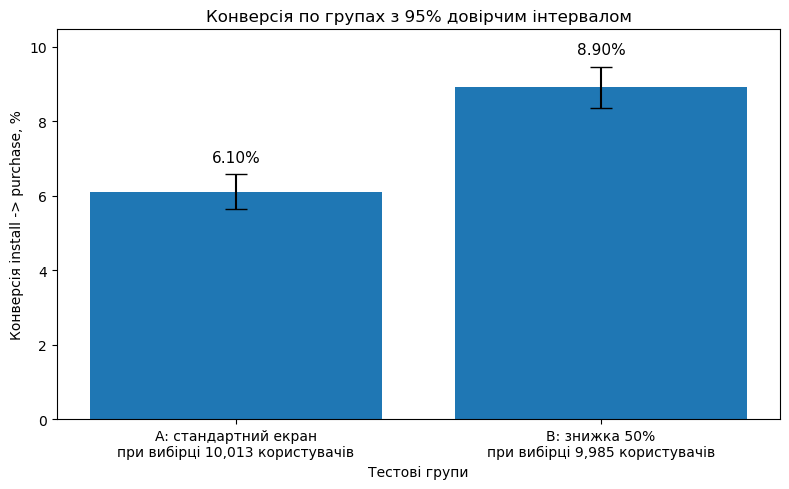

In [95]:
# Візуализація конверсій с 95% довірчими інтервалами

groups = [
    f"A: стандартний екран\nпри вибірці {users_a:,} користувачів",
    f"B: знижка 50%\nпри вибірці {users_b:,} користувачів"
]
conversion_rates = summary["conversion_rate_percent"]

errors = [
    conversion_rates - summary["ci_low_percent"],
    summary["ci_high_percent"] - conversion_rates
]

plt.figure(figsize=(8, 5))

plt.bar(groups, conversion_rates, yerr=errors, capsize=8)

plt.title("Конверсія по групах з 95% довірчим інтервалом")
plt.xlabel("Тестові групи")
plt.ylabel("Конверсія install -> purchase, %")

for i, value in enumerate(conversion_rates):
    upper_ci = summary["ci_high_percent"].iloc[i]
    
    plt.text(
        i,
        upper_ci + 0.25,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.ylim(0, summary["ci_high_percent"].max() + 1)

plt.tight_layout()
plt.show()

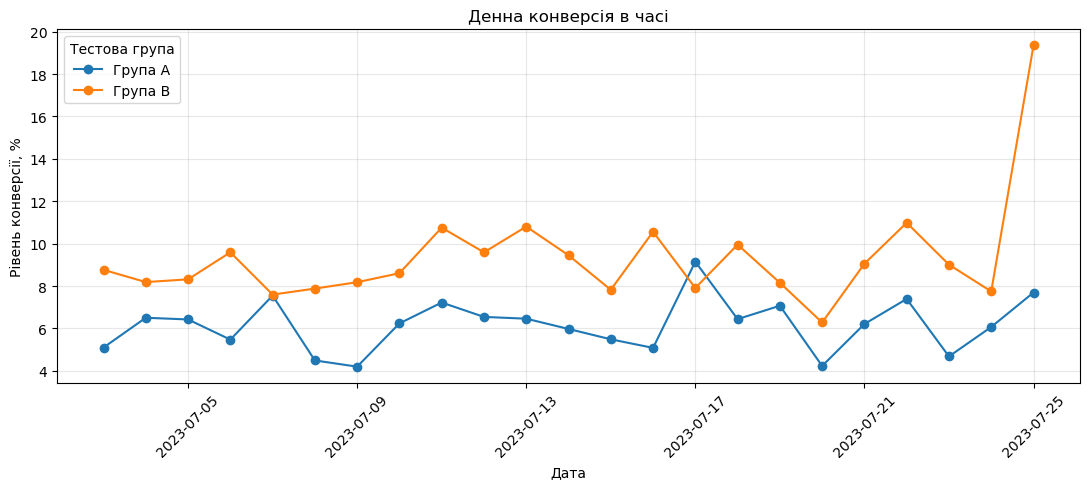

In [96]:
# 13. Графік зміни конверсії в часі

plt.figure(figsize=(11, 5))

for group in daily["test_group"].unique():

    group_data = daily[daily["test_group"] == group]

    if group == "a":
        label = "Група А"
    else:
        label = "Група В"

    plt.plot(
        group_data["date"],
        group_data["conversion_rate_percent"],
        marker="o",
        label=label
    )

plt.title("Денна конверсія в часі")
plt.xlabel("Дата")
plt.ylabel("Рівень конверсії, %")
plt.xticks(rotation=45)
plt.legend(title='Тестова група')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# Висновок

alpha = 0.05

if p_value < alpha:
    print("Результат статистично значущий.")
    print("Відхиляємо H0.")
    print("Група B демонструє значущо більш високу конверсію.")
else:
    print("Результат статистично не значущий.")
    print("Не має підстав відхиляти H0.")

Результат статистично значущий.
Відхиляємо H0.
Група B демонструє значущо більш високу конверсію.


In [48]:
# Накопичувальна конверсія в часі

# Створимо окрему таблицю
cumulative = df.groupby(
    ['date', 'test_group']
).agg(
    users=('user_id', 'nunique'),
    conversions=('conversion', 'sum')
).reset_index()


# Сортування за датою
cumulative = cumulative.sort_values(
    by=['test_group', 'date']
)


# Накопичувальна кількість користувачів
cumulative['cum_users'] = cumulative.groupby(
    'test_group'
)['users'].cumsum()


# Накопичувальна кількість конверсій
cumulative['cum_conversions'] = cumulative.groupby(
    'test_group'
)['conversions'].cumsum()


# Накопичувальна конверсія
cumulative['cum_conversion_rate'] = (
    cumulative['cum_conversions'] /
    cumulative['cum_users']
)


# Перевод у відсотки
cumulative['cum_conversion_rate_percent'] = (
    cumulative['cum_conversion_rate'] * 100
)

cumulative.head()

,date,test_group,users,conversions,cum_users,cum_conversions,cum_conversion_rate,cum_conversion_rate_percent
0,2023-07-03,a,412,21,412,21,0.050971,5.097087
2,2023-07-04,a,446,29,858,50,0.058275,5.827506
4,2023-07-05,a,436,28,1294,78,0.060278,6.027821
6,2023-07-06,a,457,25,1751,103,0.058824,5.882353
8,2023-07-07,a,477,36,2228,139,0.062388,6.238779


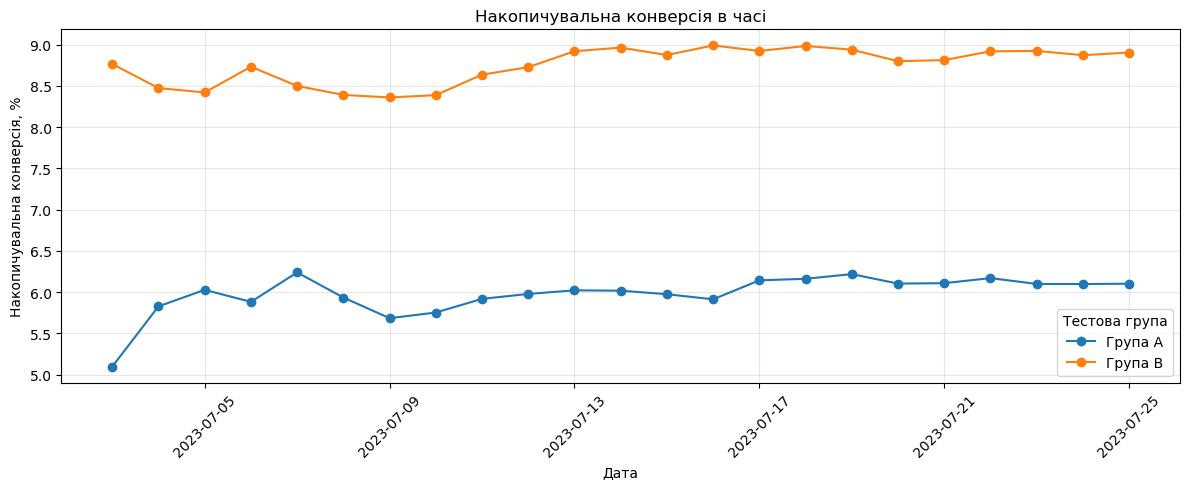

In [90]:
# Графік накопичувальної конверсії

labels = {
    'a': 'Група А',
    'b': 'Група В'
}

plt.figure(figsize=(12, 5))

for group in cumulative['test_group'].unique():

    group_data = cumulative[
        cumulative['test_group'] == group
    ]

    plt.plot(
        group_data['date'],
        group_data['cum_conversion_rate_percent'],
        marker='o',
        label=labels[group]
    )

plt.title('Накопичувальна конверсія в часі')

plt.xlabel('Дата')

plt.ylabel('Накопичувальна конверсія, %')

plt.xticks(rotation=45)

plt.legend(title='Тестова група', loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()